# MNIST Digit Recognition using Machine Learning

## Project Overview

The goal of this project is to build a machine learning model capable of recognizing and classifying handwritten digits from 0 to 9 using the MNIST dataset.

The dataset contains grayscale images of handwritten digits represented as pixel values. Each image is 28 × 28 pixels, resulting in 784 pixel features per image.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv", encoding='latin-1')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [5]:
df.info

<bound method DataFrame.info of        label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0          1       0       0       0       0       0       0       0       0   
1          0       0       0       0       0       0       0       0       0   
2          1       0       0       0       0       0       0       0       0   
3          4       0       0       0       0       0       0       0       0   
4          0       0       0       0       0       0       0       0       0   
...      ...     ...     ...     ...     ...     ...     ...     ...     ...   
41995      0       0       0       0       0       0       0       0       0   
41996      1       0       0       0       0       0       0       0       0   
41997      7       0       0       0       0       0       0       0       0   
41998      6       0       0       0       0       0       0       0       0   
41999      9       0       0       0       0       0       0       0       0   

       

In [6]:
df.shape

(42000, 785)

In [7]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

## Exploratory Data Analysis (EDA)

In [8]:
df["label"].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

## Digits Distribution Visualization

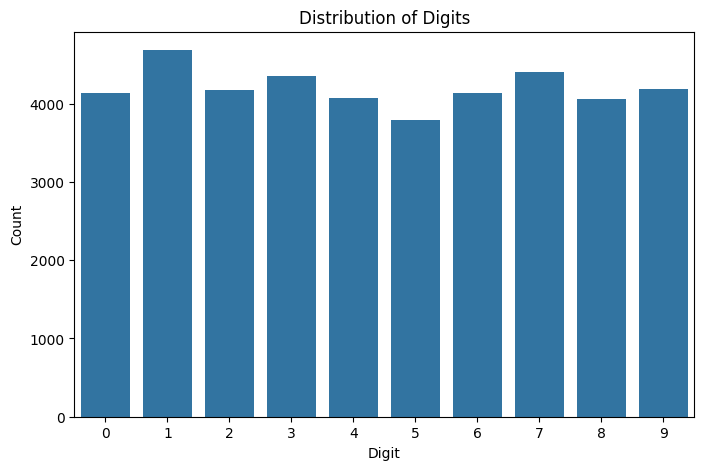

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x=df["label"])

plt.title("Distribution of Digits")
plt.xlabel("Digit")
plt.ylabel("Count")

plt.show()

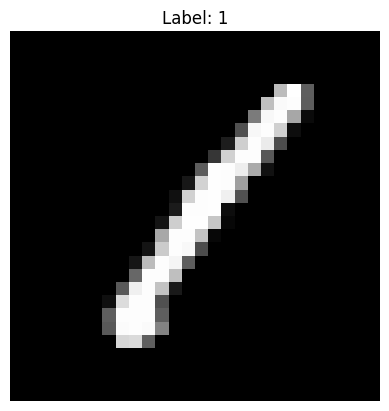

In [10]:
image = df.iloc[0, 1:].values.reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {df.iloc[0,0]}")
plt.axis("off")

plt.show()

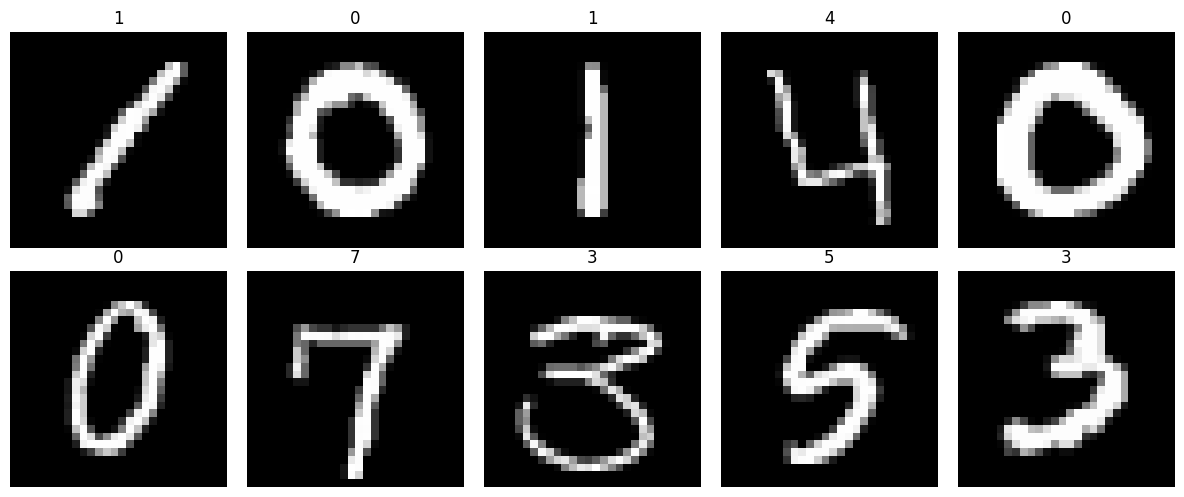

In [11]:
plt.figure(figsize=(12, 5))

for i in range(10):
    
    plt.subplot(2, 5, i + 1)
    
    image = df.iloc[i, 1:].values.reshape(28, 28)
    
    plt.imshow(image, cmap="gray")
    
    plt.title(df.iloc[i, 0])
    
    plt.axis("off")

plt.tight_layout()

plt.show()

In [12]:
X = df.drop("label", axis=1)

y = df["label"]

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [13]:
X = X / 255.0

print(X.min().min())
print(X.max().max())

0.0
1.0


## Model Training

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


## Model Evaluation

In [23]:
y_pred = model.predict(X_test)
y_pred[:10]

array([8, 1, 9, 9, 8, 6, 2, 2, 7, 1], dtype=int64)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9629761904761904


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       816
           1       0.98      0.99      0.99       909
           2       0.96      0.96      0.96       846
           3       0.96      0.95      0.96       937
           4       0.96      0.97      0.96       839
           5       0.96      0.96      0.96       702
           6       0.96      0.98      0.97       785
           7       0.97      0.95      0.96       893
           8       0.95      0.95      0.95       835
           9       0.93      0.94      0.94       838

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400



In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[802   0   1   2   2   2   4   0   3   0]
 [  0 900   4   1   1   1   1   1   0   0]
 [  3   5 810   2  11   2   4   3   5   1]
 [  1   1   6 891   2  12   0   7   9   8]
 [  1   1   1   0 811   0   7   2   0  16]
 [  1   0   2   9   0 671   8   1   6   4]
 [  4   1   1   0   2   2 769   0   6   0]
 [  1   3  12   2   5   1   0 848   2  19]
 [  1   3   6   7   3   4   4   2 797   8]
 [  2   3   2  13  11   3   0   7   7 790]]


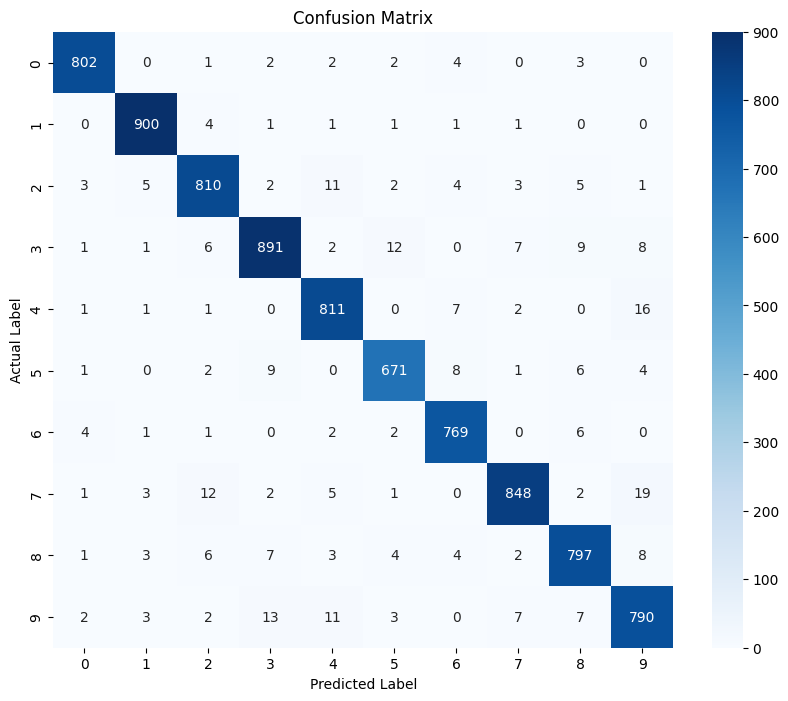

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [29]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,8,8
1,1,1
2,9,9
3,9,9
4,8,8
5,6,6
6,2,2
7,2,2
8,7,7
9,1,1


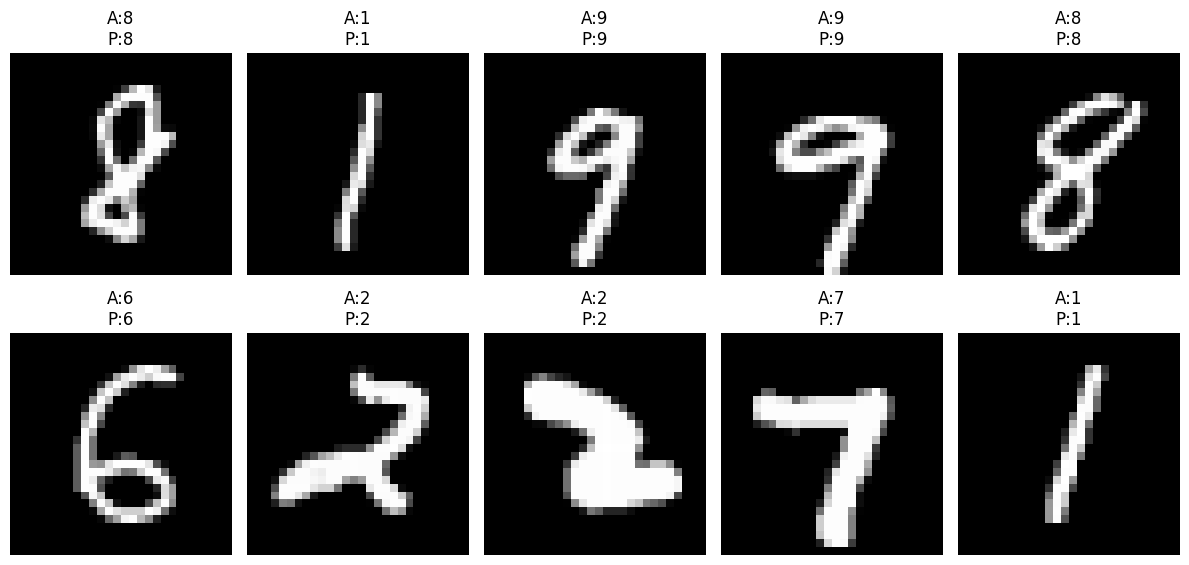

In [35]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = X_test.iloc[i].values.reshape(28, 28)

    plt.imshow(image, cmap="gray")

    plt.title(
        f"A:{y_test.iloc[i]}\nP:{y_pred[i]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
import pickle

with open("mnist_random_forest.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [32]:
with open("mnist_random_forest.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully!")

Model Loaded Successfully!


## Predict a Single Image

In [33]:
sample_image = X_test.iloc[0].values.reshape(1, -1)

prediction = loaded_model.predict(sample_image)

print("Predicted Digit:", prediction[0])
print("Actual Digit   :", y_test.iloc[0])

Predicted Digit: 8
Actual Digit   : 8


c:\New folder\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


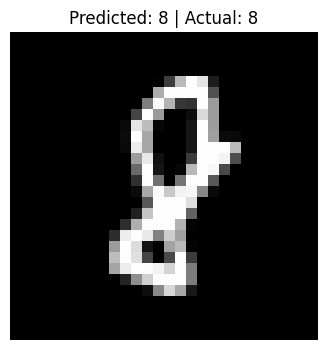

In [34]:
image = X_test.iloc[0].values.reshape(28, 28)

plt.figure(figsize=(4,4))

plt.imshow(image, cmap="gray")

plt.title(f"Predicted: {prediction[0]} | Actual: {y_test.iloc[0]}")

plt.axis("off")

plt.show()